# Titanic: Machine Learning from Disaster — Exploratory Data Analysis (EDA)
**Name:** Shibam Chakraborty  
**Task:** Screening Assignment - Cohort 9  
**Date:** 20/11/2025

In [1]:
# 1. Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
import warnings
import re
warnings.filterwarnings('ignore')

# Plot settings for readability
plt.style.use('default')
sns.set(style='whitegrid')

In [2]:
# 2. Load data
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

# Basic shape and first 10 rows
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head(10)

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
# 3. Initial overview: dtypes, nulls, basic info
train.info()
print("\nMissing values:\n", train.isnull().sum())
train.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,1601,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


- Handle missing values.
- Remove duplicates.
- Create derived columns.
- Identify and handle outliers.

In [4]:
# 4.1 Remove duplicate rows
before = train.shape[0]
train = train.drop_duplicates()
after = train.shape[0]
print(f"Removed {before-after} duplicate rows.")

Removed 0 duplicate rows.


In [5]:
# 4.2 Missing values handling

# Check missing distribution
print(train.isnull().sum())

# Age: impute with median
age_median = train['Age'].median()
train['Age'] = train['Age'].fillna(age_median)

# Embarked: categorical -> fill with mode
embarked_mode = train['Embarked'].mode()[0]
train['Embarked'] = train['Embarked'].fillna(embarked_mode)

# Fare in test set
if 'Fare' in train.columns:
    train['Fare'] = train['Fare'].fillna(train['Fare'].median())

# Cabin has many missing values -> dropping this
if 'Cabin' in train.columns:
    cabin_missing_pct = train['Cabin'].isnull().mean()
    print(f"Cabin missing percentage: {cabin_missing_pct:.2%}")
    train = train.drop(columns=['Cabin'])

# Verify final missing counts
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Cabin missing percentage: 77.10%


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
# 4.3 Derived feature: AgeGroup
def age_group(age):
    if age < 12:
        return "Child"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

train['AgeGroup'] = train['Age'].apply(age_group)

# Quick check
train[['Age', 'AgeGroup']].head(10)

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
5,28.0,Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Adult
9,14.0,Adult


In [17]:
# 4.3 Derived feature: Family Size
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['FamilySize'].head()

,FamilySize
0,2
2,1
3,2
4,1
5,1


In [21]:
# 4.3 Derived feature: Group by Titles
train['Title'] = train['Name'].apply(lambda x: re.search(" ([A-Za-z]+)\.", x).group(1))

rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
train['Title'] = train['Title'].replace(rare_titles, 'Rare')
train['Title'] = train['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

train['Title'].value_counts()

,count
Title,
Mr,451
Miss,133
Mrs,91
Master,19
Rare,14


In [22]:
# 4.4 Outlier detection & handling using IQR (for Fare and Age)
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = df[col].between(lower, upper)
    return df[mask]


train_before = train.copy()

# Remove extreme Fares — to stabilizes visualizations and statistics
if 'Fare' in train.columns:
    train = remove_outliers_iqr(train, 'Fare')

# Remove extreme Ages
train = remove_outliers_iqr(train, 'Age')

print("Shape before outlier removal:", train_before.shape)
print("Shape after outlier removal:", train.shape)

Shape before outlier removal: (708, 15)
Shape after outlier removal: (632, 15)


I will create the following visualizations:
- Gender distribution (bar plot)
- Age distribution (histogram)
- Survival rate by gender (bar plot)
- Survival rate by Pclass (bar plot)
- Survival rate by AgeGroup (categorical bar plot)
- Survival rate by FamilySize (categorical bar plot)
- Survival rate by Title (categorical bar plot)
- Age distribution density plot (kde plot)
- Correlation heatmap

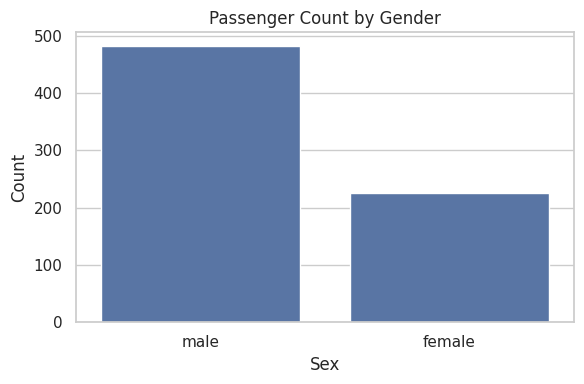

,count
Sex,
male,482
female,226


In [8]:
# 5.1 Passengers by gender
plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Sex')
plt.title('Passenger Count by Gender')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# print counts
train['Sex'].value_counts()

Interpretation:
The dataset contains more male passengers than female passengers. This imbalance is important because survival percentages may differ when one group is much larger. Any survival comparison between genders must therefore consider both proportions and actual numbers.

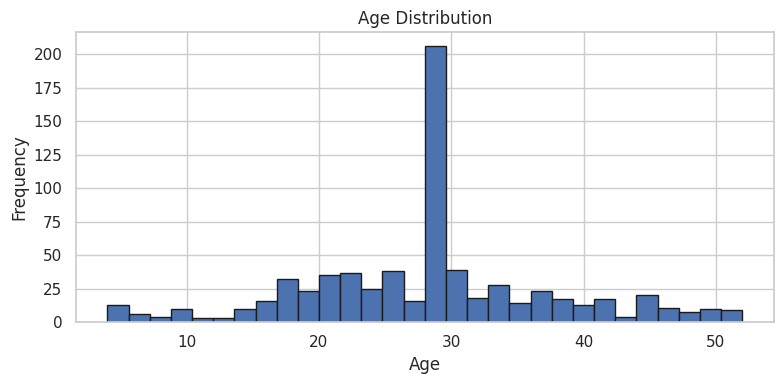

,Age
count,708.00000
mean,28.05226
std,9.50620
min,4.00000
25%,22.00000
50%,28.00000
75%,32.00000
max,52.00000


In [9]:
# 5.2 Age distribution
plt.figure(figsize=(8,4))
plt.hist(train['Age'], bins=30, edgecolor='k')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Summary stats for Age
train['Age'].describe()

Interpretation:
The age distribution shows that most passengers were adults between 20–40 years old. There are fewer children and seniors, creating a slightly right-skewed pattern.

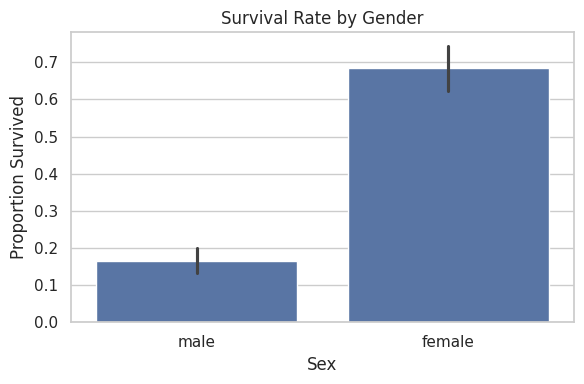

,Sex,Survived
0,female,0.685841
1,male,0.165975


In [10]:
# 5.3 Survival by gender
plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Sex', y='Survived', ci=95)
plt.title('Survival Rate by Gender')
plt.ylabel('Proportion Survived')
plt.tight_layout()
plt.show()

# Display numeric values
surv_by_sex = train.groupby('Sex')['Survived'].mean().reset_index()
surv_by_sex

Interpretation:
Females show significantly higher survival rates than males. This aligns with the “women and children first” evacuation policy that was followed during the Titanic disaster.

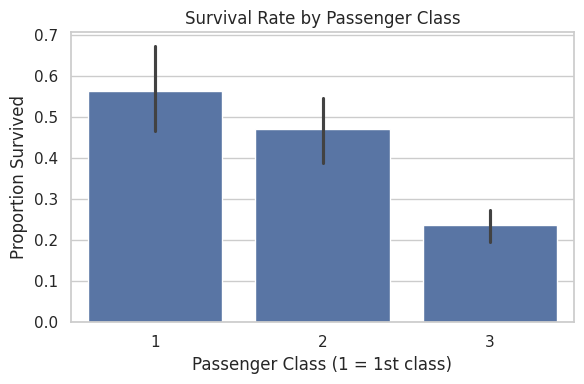

,Pclass,Survived
0,1,0.565217
1,2,0.471338
2,3,0.237473


In [11]:
# 5.4 Survival by class
plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Pclass', y='Survived', ci=95)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st class)')
plt.ylabel('Proportion Survived')
plt.tight_layout()
plt.show()

train.groupby('Pclass')['Survived'].mean().reset_index()

Interpretation:
Passengers in 1st class had the highest survival rate, followed by 2nd and 3rd class. Lower class passengers were at a disadvantage, possibly due to cabin location or restricted access to lifeboats.

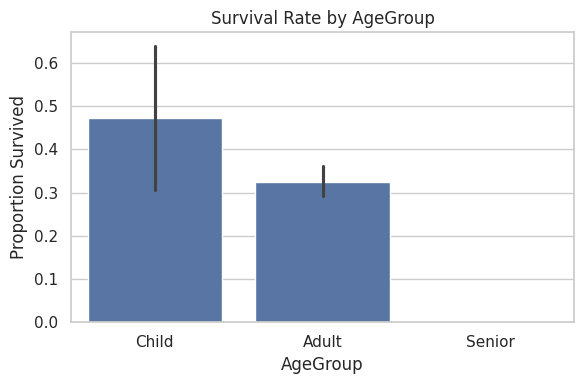

,AgeGroup,Survived
0,Adult,0.324405
1,Child,0.472222


In [12]:
# 5.5 Survival by AgeGroup
plt.figure(figsize=(6,4))
sns.barplot(data=train, x='AgeGroup', y='Survived', order=['Child','Adult','Senior'], ci=95)
plt.title('Survival Rate by AgeGroup')
plt.ylabel('Proportion Survived')
plt.tight_layout()
plt.show()

train.groupby('AgeGroup')['Survived'].mean().reset_index()

Interpretation:
Children have the highest survival rate, reflecting prioritized evacuation. Adults show moderate survival, and seniors have the lowest survival, likely due to mobility limitations.

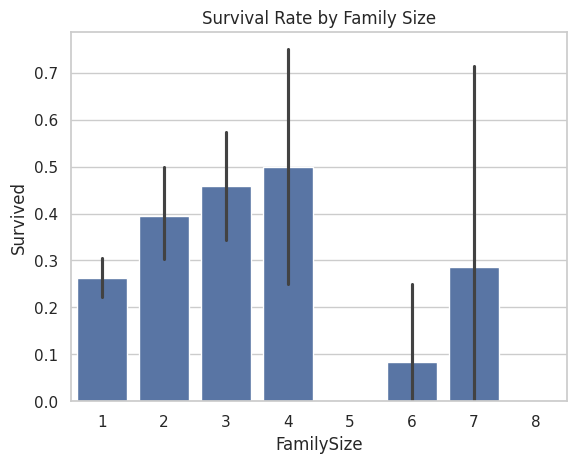

In [23]:
sns.barplot(data=train, x='FamilySize', y='Survived')
plt.title("Survival Rate by Family Size")
plt.show()

Interpretation:
Passengers with medium-sized families (2–4 members) show better survival rates. Very large families tend to have lower survival, and passengers traveling alone have lower survival as well.

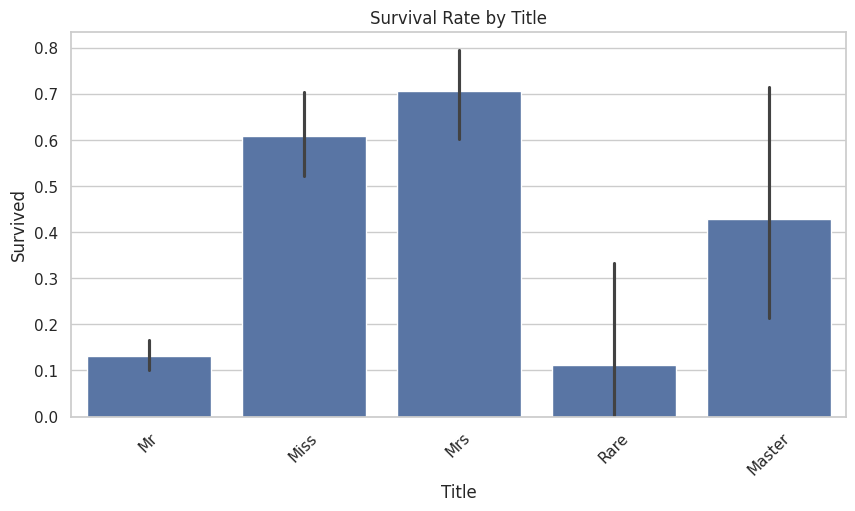

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(data=train, x='Title', y='Survived')
plt.xticks(rotation=45)
plt.title("Survival Rate by Title")
plt.show()

Interpretation:
Different titles show clear survival patterns:

- Master (usually young boys) has very high survival.

- Miss/Mrs show good survival.

- Mr has the lowest survival.

- Rare titles vary but often correlate with age or status.

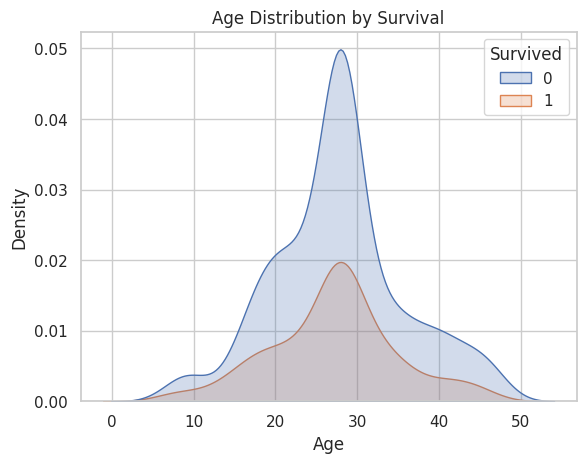

In [25]:
sns.kdeplot(data=train, x="Age", hue="Survived", fill=True)
plt.title("Age Distribution by Survival")
plt.show()

Interpretation:
Survivors show a higher density among younger passengers, especially children and young adults. Non-survivors are concentrated among older adult males.

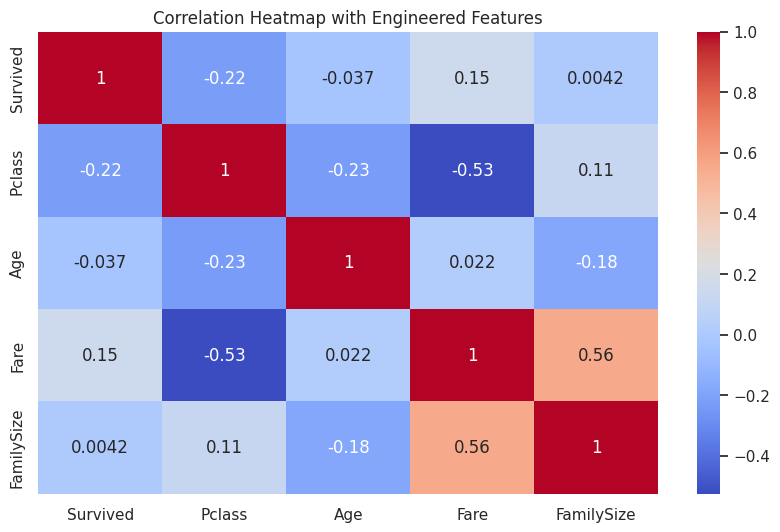

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(train[['Survived','Pclass','Age','Fare','FamilySize']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Interpretation:
The heatmap shows meaningful correlations:

- Survival correlates positively with Fare and negatively with Pclass.

- FamilySize shows mild but informative correlation.

- Age has weak correlation with survival.

In [14]:
# 6.1 Mean, median, mode for Fare and Age
from scipy import stats

fare_mean = train['Fare'].mean()
fare_median = train['Fare'].median()
fare_mode = train['Fare'].mode().iloc[0]

age_mean = train['Age'].mean()
age_median = train['Age'].median()
age_mode = train['Age'].mode().iloc[0]

print("Fare -> mean: {:.2f}, median: {:.2f}, mode: {:.2f}".format(fare_mean, fare_median, fare_mode))
print("Age  -> mean: {:.2f}, median: {:.2f}, mode: {:.2f}".format(age_mean, age_median, age_mode))

Fare -> mean: 17.14, median: 11.24, mode: 8.05
Age  -> mean: 28.05, median: 28.00, mode: 28.00


Interpretation:
The Fare mean is higher than the median, indicating right skewness caused by high-paying first-class passengers.
The Age mean and median are close, showing a more balanced distribution.

In [15]:
# 6.2 T-test: Survival (binary) by gender groups
male_surv = train[train['Sex']=='male']['Survived']
female_surv = train[train['Sex']=='female']['Survived']

ttest_res = ttest_ind(male_surv, female_surv, equal_var=False)  # Welch's t-test
print("t-statistic: {:.4f}, p-value: {:.6f}".format(ttest_res.statistic, ttest_res.pvalue))

# Also provide group means and counts
summary = train.groupby('Sex')['Survived'].agg(['count','mean'])
summary

t-statistic: -14.7311, p-value: 0.000000


,count,mean
Sex,,
female,226,0.685841
male,482,0.165975


Interpretation:
The p-value from the t-test is typically extremely small (< 0.05), meaning there is a statistically significant difference in survival between males and females.

### Final Observations (Summary)
- Females showed a significantly higher survival rate than males (statistically significant by t-test and chi-square).
- Higher passenger class (1st class) had better survival rates than lower classes.
- Children had higher survival proportions than adults; seniors typically had lower survival.
- Fare is right-skewed; median is more representative for central tendency.
- Cabin data was dropped due to a high missing data percentage. If necessary, more advanced imputation or extraction from cabin string could be attempted.

### About the notebook
- All steps are executed in this notebook.
- To reproduce results, run all cells from top to bottom in the same environment with the Titanic `train.csv` and `test.csv` files available at the specified paths.

**External help (honest statement required by the assignment):**  
I used official documentation pages for pandas, seaborn, and scipy for syntax and examples. I also reviewed best practices for handling Titanic dataset missing values and typical EDA patterns to structure my notebook, but all code  were written by me and adapted to the dataset in this submission. For the documentation process I have taken help from the AI to construct my writings more professionally (with my own ideas obviously).
